### Import

In [70]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Loading Dataset

In [71]:
folder_path = "dataset"
dataframes = []
for file in os.listdir(folder_path):
    if file.startswith("openaq") and file.endswith(".csv"):
        full_path = os.path.join(folder_path, file)
        dfm = pd.read_csv(full_path)
        dataframes.append(dfm)
df = pd.concat(dataframes, ignore_index=True)

In [72]:
df.head()

,location_id,location_name,parameter,value,unit,datetimeUtc,datetimeLocal,timezone,latitude,longitude,country_iso,isMobile,isMonitor,owner_name,provider
0,100,Badhoevedorp-Sloterweg,co,354.0,µg/m³,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,NaN,NaN,NaN,Unknown Governmental Organization,EEA
1,100,Badhoevedorp-Sloterweg,co,327.0,µg/m³,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,NaN,NaN,NaN,Unknown Governmental Organization,EEA
2,100,Badhoevedorp-Sloterweg,co,221.0,µg/m³,2025-01-01T05:00:00Z,2025-01-01T06:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,NaN,NaN,NaN,Unknown Governmental Organization,EEA
3,100,Badhoevedorp-Sloterweg,co,241.0,µg/m³,2025-01-01T06:00:00Z,2025-01-01T07:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,NaN,NaN,NaN,Unknown Governmental Organization,EEA
4,100,Badhoevedorp-Sloterweg,co,251.0,µg/m³,2025-01-01T07:00:00Z,2025-01-01T08:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,NaN,NaN,NaN,Unknown Governmental Organization,EEA


In [73]:
print(df["country_iso"].isna().sum())

383965


In [74]:
len(df)

383965

### Data Cleaning

In [75]:
df=df.drop("country_iso", axis=1)

In [76]:
print(df["isMobile"].isna().sum())

383965


In [77]:
print(df["isMonitor"].isna().sum())

383965


In [78]:
df=df.drop("isMobile", axis=1)
df=df.drop("isMonitor", axis=1)

In [79]:
df.head()

,location_id,location_name,parameter,value,unit,datetimeUtc,datetimeLocal,timezone,latitude,longitude,owner_name,provider
0,100,Badhoevedorp-Sloterweg,co,354.0,µg/m³,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,Unknown Governmental Organization,EEA
1,100,Badhoevedorp-Sloterweg,co,327.0,µg/m³,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,Unknown Governmental Organization,EEA
2,100,Badhoevedorp-Sloterweg,co,221.0,µg/m³,2025-01-01T05:00:00Z,2025-01-01T06:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,Unknown Governmental Organization,EEA
3,100,Badhoevedorp-Sloterweg,co,241.0,µg/m³,2025-01-01T06:00:00Z,2025-01-01T07:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,Unknown Governmental Organization,EEA
4,100,Badhoevedorp-Sloterweg,co,251.0,µg/m³,2025-01-01T07:00:00Z,2025-01-01T08:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,Unknown Governmental Organization,EEA


array([[<Axes: title={'center': 'location_id'}>,
        <Axes: title={'center': 'value'}>],
       [<Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>]], dtype=object)

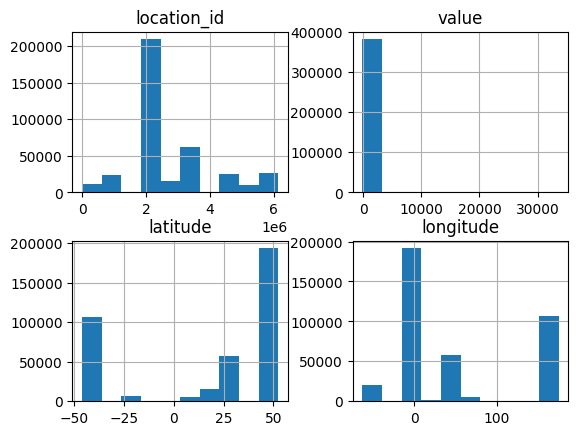

In [80]:
df.hist()

### Pivot the Data

In [81]:
df["datetimeUtc"] = pd.to_datetime(df["datetimeUtc"])
df_wide = df.pivot_table(index=["location_id", "datetimeUtc"], columns="parameter", values="value").reset_index()

In [82]:
df_wide.head()

parameter,location_id,datetimeUtc,co,no,no2,o3,pm1,pm10,pm25,relativehumidity,so2,temperature,um003
0,100,2025-01-01 01:00:00+00:00,354.0,NaN,10.0,NaN,NaN,148.3,109.8,NaN,NaN,NaN,NaN
1,100,2025-01-01 02:00:00+00:00,327.0,NaN,11.8,NaN,NaN,66.6,60.9,NaN,NaN,NaN,NaN
2,100,2025-01-01 05:00:00+00:00,221.0,NaN,2.7,NaN,NaN,0.5,4.1,NaN,NaN,NaN,NaN
3,100,2025-01-01 06:00:00+00:00,241.0,NaN,4.3,NaN,NaN,4.4,7.7,NaN,NaN,NaN,NaN
4,100,2025-01-01 07:00:00+00:00,251.0,NaN,3.5,NaN,NaN,9.3,7.2,NaN,NaN,NaN,NaN


In [83]:
features = ["co2", "no3", "temperature", "pm10", "pm25", "relativehumidity"]
df_pca = df_wide[features].fillna(df_wide[features].mean())
df_pca.head()





KeyError: "['co2', 'no3'] not in index"

In [ ]:
print(df_wide[features].isna().sum())
print(df_wide[features].shape)
print(df_wide[features].dropna().shape)

In [45]:
print(df_pca.shape)
df_pca.head()

(135901, 6)


parameter,co,no2,o3,pm10,pm25,so2
0,354.0,10.0,46.5308,148.3,109.8,1.837846
1,327.0,11.8,46.5308,66.6,60.9,1.837846
2,221.0,2.7,46.5308,0.5,4.1,1.837846
3,241.0,4.3,46.5308,4.4,7.7,1.837846
4,251.0,3.5,46.5308,9.3,7.2,1.837846


In [46]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

In [47]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

df_pca_result = pd.DataFrame(principal_components,columns=["PC1", "PC2"])

In [48]:
print(df_pca.shape)

(135901, 6)


In [49]:
features = ["co2", "no3", "temperature", "pm10", "pm25", "relativehumidity"]
df_pca = df_wide[features].copy()

KeyError: "['co2', 'no3'] not in index"

# Replace infinities

In [50]:
df_pca = df_pca.replace([np.inf, -np.inf], np.nan)

# fill missing values

In [56]:
df_pca = df_pca.fillna(df_pca.mean())

# Standardize and PCA

In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)


pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

df_pca_result = pd.DataFrame(principal_components, columns=["PC1", "PC2"])

In [58]:
loadings = pd.DataFrame( pca.components_.T, columns=["PC1", "PC2"], index=features )

In [59]:
location_lookup = df[["location_id", "location_name"]].drop_duplicates()
print(loadings)

                       PC1       PC2
co2               0.281026  0.733426
no3               0.494457  0.376970
temperature      -0.391810  0.055133
pm10              0.558471 -0.269342
pm25              0.459291 -0.476136
relativehumidity  0.013534 -0.132998


In [60]:
 print(df["location_name"].unique()[:20])

['Badhoevedorp-Sloterweg' 'Amsterdam-Hoogtij' 'Amsterdam-Einsteinweg'
 'Kaiapoi' 'AIRVAULT - Stade Laillé' 'place de VERDUN' 'Niort Venise'
 'Niort - Tassigny' 'Zoodyssée Chizé' 'AMBES' 'LE TEMPLE' 'BASSENS'
 'Bordeaux_GAUTIER' 'GRAND PARC' 'MERIGNAC' 'TALENCE' 'TARTAS Pelletrin'
 'MONT-DE-MARSAN - MIDOUZE' 'SAINT-CROUTS' 'ANGLET']


In [61]:
 location_lookup = df[["location_id", "location_name"]].drop_duplicates()

In [62]:
df_wide = df_wide.merge(location_lookup, on="location_id", how="left")

In [63]:
print(df_wide.columns)

Index(['location_id', 'datetimeUtc', 'co', 'no', 'no2', 'o3', 'pm1', 'pm10',
       'pm25', 'relativehumidity', 'so2', 'temperature', 'um003',
       'location_name'],
      dtype='object')


In [64]:
industrial = [
    "Amsterdam-Hoogtij",
    "BASSENS",
    "AMBES",
    "LE TEMPLE"
]

df_wide["zone"] = df_wide["location_name"].apply(
    lambda x: "Industrial" if x in industrial else "Residential"
)

In [65]:
df_pca_result["zone"] = df_wide.loc[df_pca.index, "zone"].values

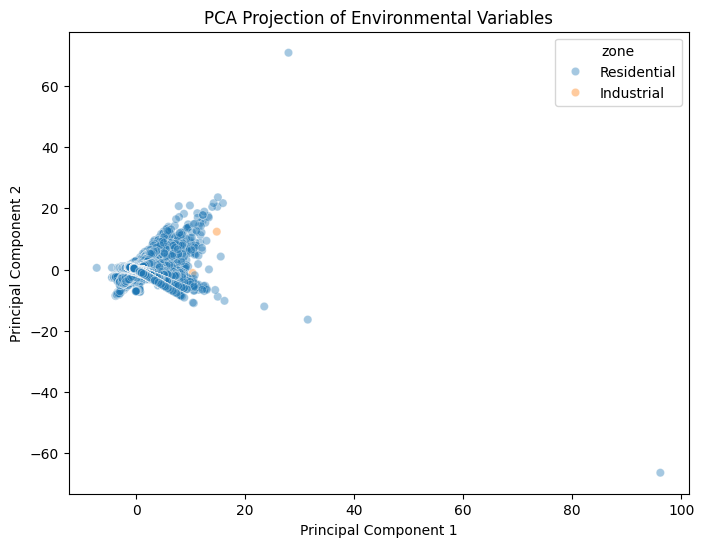

In [66]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_pca_result,
    x="PC1",
    y="PC2",
    hue="zone",
    alpha=0.4
)

plt.title("PCA Projection of Environmental Variables")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [67]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.30606023 0.17161354]
Total variance explained: 0.47767376854093524


In [68]:
print(loadings)

                       PC1       PC2
co2               0.281026  0.733426
no3               0.494457  0.376970
temperature      -0.391810  0.055133
pm10              0.558471 -0.269342
pm25              0.459291 -0.476136
relativehumidity  0.013534 -0.132998
